# 4차시 ― 머신러닝 직접 만들기 · 붓꽃 품종 분류

> 2차시에서는 Hugging Face `pipeline` 으로 이미 만들어진 모델을 **가져다 써** 보았습니다. 이번 노트북에서는 scikit-learn 으로 분류 모델을 **직접 학습**시켜 봅니다. 데이터를 준비하고, 모델을 학습시키고, 성능을 평가하는 머신러닝의 전체 흐름을 한 번에 경험합니다.
>
> 짝꿍 노트북 **s4-04(집값 예측)** 가 숫자 값을 맞히는 **회귀**였다면, 이 노트북은 **어느 품종인지** 맞히는 **분류**입니다.
>
> **실행 방법**: 코드 셀을 클릭하고 `Shift + Enter`. 위에서 아래로 순서대로 실행하세요. 앞 셀에서 만든 변수를 뒤 셀에서 사용합니다.

**다루는 내용**
1. 분류란 무엇인가 (회귀와의 차이)
2. 데이터 불러오기 · DataFrame 으로 탐색
3. 입력(X) · 정답(y) 나누기, 학습/평가 분리
4. 모델 3종 학습 · 비교
5. 평가 — 정확도 · 혼동행렬 · classification_report
6. 왜 그렇게 분류했나 — 결정 트리 · 특성 중요도
7. 새 데이터 예측해 보기
8. (도전) 타이타닉 생존 분류 맛보기
9. 정리 · 다음 차시 예고

> 📌 **✏️ 표시가 붙은 "연습문제"는 직접 풀어 보는 칸입니다.** 먼저 스스로 작성해 본 뒤 정답을 확인하세요.

## 1. 분류란 무엇인가

**머신러닝**은 사람이 규칙을 일일이 적는 대신, **데이터로부터 규칙(패턴)을 스스로 배우게** 하는 방법입니다. 그중에서도 정답이 있는 데이터로 배우는 방식을 **지도학습**이라 하고, 지도학습은 다시 두 가지로 나뉩니다.

| 구분 | 무엇을 맞히나 | 정답의 형태 | 예시 |
|---|---|---|---|
| **회귀** | 연속된 **숫자 값** | 실수 (예: 320,500,000원) | 집값 예측 (s4-04) |
| **분류** | 정해진 **범주(클래스)** | 라벨 (예: A·B·C 중 하나) | 붓꽃 품종 · 스팸/정상 메일 |

이번 노트북의 문제는 분류입니다. 꽃잎·꽃받침의 길이와 너비를 보고 **붓꽃이 세 품종 중 어느 것인지** 맞힙니다. 정답이 "320,500,000" 같은 숫자가 아니라 "setosa / versicolor / virginica" 중 하나라는 점이 회귀와의 가장 큰 차이입니다.

## 2. 라이브러리 불러오기와 데이터 준비

분류에 필요한 라이브러리를 먼저 불러옵니다. 이번 데이터는 scikit-learn 안에 **내장**되어 있어 파일을 따로 내려받지 않아도 됩니다.

In [1]:
# scikit-learn(sklearn): 파이썬의 대표 머신러닝 라이브러리입니다.
# Colab 에는 아래 라이브러리가 대부분 이미 설치되어 있습니다.
# 만약 설치가 안 되어 있다면 아래 주석(#)을 지우고 한 번 실행하세요.
# !pip install -q scikit-learn pandas matplotlib seaborn

import numpy as np                 # 숫자 계산 (약어: np)
import pandas as pd                # 표(DataFrame) 형태 데이터 다루기 (약어: pd)
import matplotlib.pyplot as plt    # 그래프 그리기 (약어: plt)
import seaborn as sns              # 그래프를 더 보기 좋게 (약어: sns)

import warnings
warnings.filterwarnings('ignore')  # 실행에 영향 없는 경고 메시지를 숨깁니다.

print("라이브러리 준비 완료")

라이브러리 준비 완료


### 2.1 붓꽃 데이터 불러오기

`load_iris()` 는 붓꽃 데이터셋을 돌려줍니다. 통계학에서 아주 유명한 예제 데이터로, 붓꽃 150송이를 측정한 표입니다.

- **입력(특성)**: 꽃받침 길이·너비, 꽃잎 길이·너비 (총 4개, 단위 cm)
- **정답(품종)**: setosa · versicolor · virginica (3종, 각 50송이)

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()   # 붓꽃 데이터를 통째로 담은 객체

# iris 안에 무엇이 들어 있는지 키 목록을 봅니다.
print(iris.keys())
# 결과 예: dict_keys(['data', 'target', 'frame', 'target_names', ...])

print("특성 이름:", iris.feature_names)   # 입력 4개의 이름
print("품종 이름:", iris.target_names)    # 정답 3개의 이름
print("데이터 크기:", iris.data.shape)    # (150, 4) = 150송이 x 4개 특성

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
특성 이름: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
품종 이름: ['setosa' 'versicolor' 'virginica']
데이터 크기: (150, 4)


### 2.2 표(DataFrame)로 바꿔서 보기

`iris.data` 는 숫자만 든 배열이라 한눈에 보기 어렵습니다. 3차시에서 배운 pandas `DataFrame` 으로 바꾸면 엑셀 표처럼 컬럼 이름과 함께 볼 수 있습니다.

In [3]:
# 1) 입력 데이터(4개 특성)를 DataFrame 으로 만듭니다.
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 2) 정답(품종)도 컬럼으로 추가합니다.
#    iris.target 은 0,1,2 숫자입니다. 사람이 읽기 쉽게 품종 이름도 함께 넣습니다.
df['target'] = iris.target                              # 0 / 1 / 2 (숫자 라벨)
df['species'] = iris.target_names[iris.target]          # setosa / versicolor / virginica

# .head(): 처음 5개 행을 미리 봅니다.
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
# .describe(): 수치형 컬럼의 기초 통계량 (개수·평균·표준편차·최소/최대 등)
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# .value_counts(): 각 품종이 몇 개씩 있는지 셉니다.
# 세 품종이 50개씩 고르게 들어 있어, 한쪽으로 치우치지 않은 균형 잡힌 데이터입니다.
print(df['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### 2.3 그림으로 살펴보기

숫자만 봐서는 품종이 잘 나뉘는지 알기 어렵습니다. **산점도**로 두 특성을 양 축에 놓고 품종별로 색을 다르게 칠해 보면, 품종이 공간에서 어떻게 떨어져 있는지 한눈에 보입니다.

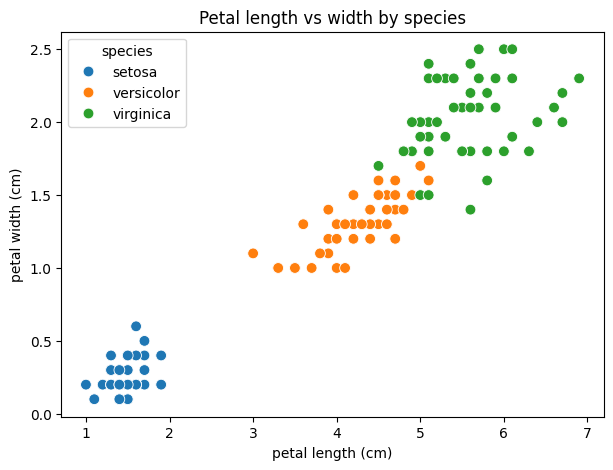

In [6]:
# 꽃잎(petal) 길이 vs 너비 산점도. 품종(species)별로 색을 다르게 표시합니다.
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='petal length (cm)',   # 가로축: 꽃잎 길이
    y='petal width (cm)',    # 세로축: 꽃잎 너비
    hue='species',           # 품종별 색 구분
    s=60                     # 점 크기
)
plt.title('Petal length vs width by species')
plt.show()

# 해석: setosa(왼쪽 아래)는 다른 두 품종과 확실히 떨어져 있어 쉽게 구분됩니다.
#       versicolor 와 virginica 는 일부 겹쳐서, 이 둘을 가르는 게 분류의 핵심입니다.

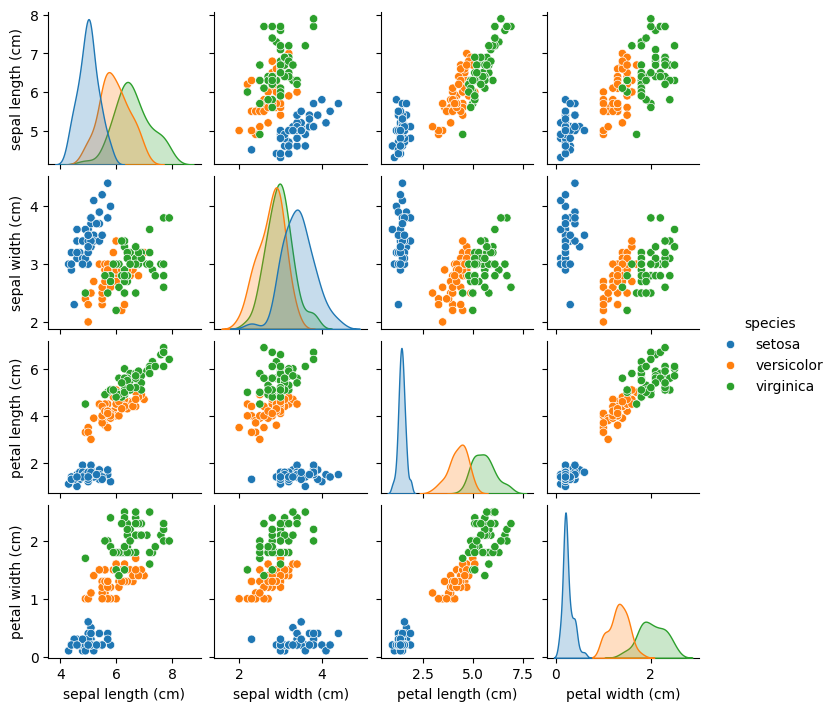

In [7]:
# pairplot: 4개 특성을 둘씩 모든 조합으로 산점도를 그려 줍니다(특성 간 관계 한눈에 보기).
# 대각선은 각 특성의 분포(히스토그램)입니다. (그리는 데 몇 초 걸릴 수 있습니다.)
sns.pairplot(df, vars=iris.feature_names, hue='species', height=1.8)
plt.show()

# 해석: 꽃잎(petal) 관련 두 특성에서 품종이 가장 잘 나뉩니다.
#       즉 꽃잎 정보가 품종을 구분하는 데 특히 중요하다는 힌트를 얻을 수 있습니다.

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 1 꽃받침으로 산점도 그리기</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 위 산점도는 <b>꽃잎(petal)</b>으로 그렸습니다. 같은 방식으로 <b>꽃받침(sepal)</b>의 길이·너비를 두 축에 놓고 산점도를 그려, 품종이 더 잘 나뉘는지 눈으로 확인하세요.<br><b>힌트</b> &nbsp; 앞의 꽃잎 산점도 코드에서 <code>x</code>·<code>y</code> 축만 꽃받침 쪽으로 바꾸면 됩니다. 컬럼 이름이 헷갈리면 <code>df.columns</code> 로 확인하세요.<br><b>예상</b> &nbsp; 꽃잎 때보다 versicolor·virginica가 더 겹쳐 구분이 어렵다
</div>
</div>

In [10]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

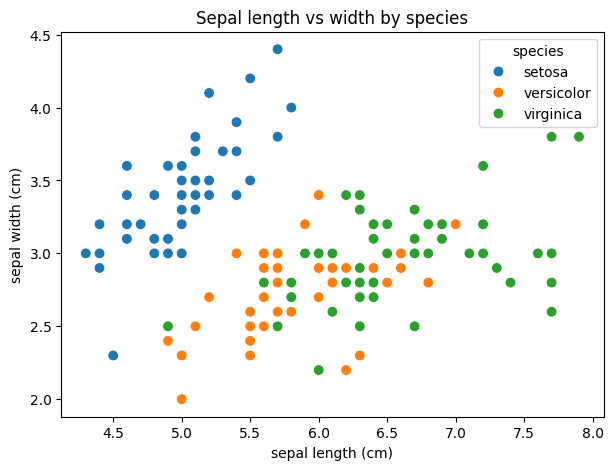

In [11]:
# ✏️ 연습문제 1 — 빈칸(____)을 채워 보세요
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x='sepal length (cm)',          # 꽃받침 길이
    y='sepal width (cm)',          # 꽃받침 너비
    hue='species', s=60
)
plt.title('Sepal length vs width by species')
plt.show()


## 3. 입력(X) · 정답(y) 나누기, 학습/평가 분리

머신러닝 모델에게는 **입력과 정답을 따로** 건네줍니다.

- **X (입력/특성)**: 예측에 사용할 자료 — 여기서는 4개 측정값
- **y (정답/라벨)**: 맞혀야 하는 답 — 여기서는 품종(0·1·2)

In [12]:
# X: 입력으로 쓸 4개 특성만 모읍니다. (species, target 같은 정답 컬럼은 제외)
X = iris.data            # 모양 (150, 4)
# y: 정답(품종). 숫자 라벨 0/1/2 를 사용합니다.
y = iris.target          # 모양 (150,)

print("X 크기:", X.shape)   # (150, 4)
print("y 크기:", y.shape)   # (150,)
print("y 앞 10개:", y[:10]) # [0 0 0 0 0 0 0 0 0 0]  (앞쪽은 모두 setosa)

X 크기: (150, 4)
y 크기: (150,)
y 앞 10개: [0 0 0 0 0 0 0 0 0 0]


### 3.1 왜 학습용과 평가용으로 나누나

가진 데이터를 **전부** 학습에 쓰면, 모델이 그 데이터의 답을 외워 버려 점수가 좋아 보일 수 있습니다. 하지만 정작 **처음 보는 새 데이터**에서는 틀릴 수 있는데, 이걸 미리 알 길이 없습니다(이를 과적합이라 합니다).

그래서 데이터를 미리 둘로 나눕니다. **학습용(train)** 으로만 공부시키고, 떼어 둔 **평가용(test)** 으로 처음 보는 문제처럼 점수를 매깁니다. `train_test_split()` 이 이 작업을 한 줄로 해 줍니다.

In [13]:
from sklearn.model_selection import train_test_split

# train_test_split: 데이터를 랜덤하게 섞은 뒤 학습용/평가용으로 나눕니다.
#   - test_size=0.2 : 전체의 20%를 평가용으로 (나머지 80%는 학습용)
#   - random_state=42 : 난수를 고정해, 실행할 때마다 같은 분할이 나오게 합니다.
#   - stratify=y : 세 품종의 비율을 학습/평가 양쪽에 똑같이 유지합니다.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("학습용 X:", X_train.shape)   # (120, 4)  = 150 의 80%
print("평가용 X:", X_test.shape)    # (30, 4)   = 150 의 20%
print("학습용 정답 분포:", np.bincount(y_train))  # 품종별 개수 (40,40,40)
print("평가용 정답 분포:", np.bincount(y_test))   # 품종별 개수 (10,10,10)

학습용 X: (120, 4)
평가용 X: (30, 4)
학습용 정답 분포: [40 40 40]
평가용 정답 분포: [10 10 10]


## 4. 모델 학습하고 비교하기

이제 분류 모델을 만들어 학습시킵니다. scikit-learn 모델은 사용법이 거의 똑같아서, 어떤 모델이든 다음 두 단계로 씁니다.

1. `모델.fit(X_train, y_train)` — 학습용 데이터로 패턴을 **배웁니다**.
2. `모델.predict(X_test)` — 배운 것으로 새 데이터의 답을 **예측합니다**.

성격이 다른 분류기 세 가지를 같은 방식으로 학습시켜 비교합니다.

| 모델 | 한 줄 설명 |
|---|---|
| **LogisticRegression** | 이름은 회귀지만 **분류** 모델. 특성을 가중합해 클래스 확률을 계산합니다. |
| **DecisionTreeClassifier** | "꽃잎 길이가 2.5 보다 크면…" 같은 **예/아니오 질문**을 잇따라 던져 나눕니다. |
| **KNeighborsClassifier** | 새 꽃과 **가장 가까운 이웃 k개**의 품종을 보고 다수결로 정합니다. |

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">⚠️ 흔한 실수 · '학습에 쓴 데이터'로 성적을 매기면 — 결과를 예측해 보세요</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>상황</b> &nbsp; 방금 나눈 <code>X_train</code> 으로 모델을 학습시킨 뒤, <b>같은 <code>X_train</code></b> 으로 정확도를 잽니다.<br><b>예측</b> &nbsp; 학습 데이터로 잰 점수와, 못 본 <code>X_test</code> 로 잰 점수 — 어느 쪽이 높을까요? 얼마나 차이 날까요?
</div>
</div>

In [14]:
# ⚠️ 흔한 실수 — 학습에 쓴 데이터로 평가 (본 문제로 시험 보기)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print('학습 데이터로 평가 :', accuracy_score(y_train, tree.predict(X_train)))  # 거의 1.0
print('평가 데이터로 평가 :', accuracy_score(y_test,  tree.predict(X_test)))   # 진짜 실력

학습 데이터로 평가 : 1.0
평가 데이터로 평가 : 0.9333333333333333


<details>
<summary><b>🔑 왜 이렇게 되나 · 올바른 방법</b></summary>

결정 트리는 학습 데이터를 <b>통째로 외울</b> 수 있어, 본 문제로 시험 보면 정확도가 거의 <b>100%</b> 로 나옵니다. 하지만 이건 실력이 아니라 <b>암기</b>예요. 못 본 <code>X_test</code> 로 재면 점수가 뚝 떨어져 <b>진짜 성능</b>이 드러납니다. 그래서 데이터를 학습용·평가용으로 나누는 겁니다.

```python
# 반드시 '학습에 안 쓴' X_test 로 평가한다
acc = accuracy_score(y_test, tree.predict(X_test))
```

👉 <b>교훈</b> : 점수가 <b>너무 완벽하면</b> 실력이 아니라 <b>커닝(데이터 누수)</b>을 의심하세요.

</details>

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 세 모델을 딕셔너리에 담아 둡니다. {모델이름: 모델객체}
models = {
    "LogisticRegression": LogisticRegression(max_iter=200),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "KNN":                KNeighborsClassifier(n_neighbors=5),
}

results = {}  # 모델별 정확도를 저장할 빈 딕셔너리

for name, model in models.items():        # 모델을 하나씩 꺼내서
    model.fit(X_train, y_train)           # 1) 학습용으로 학습
    y_pred = model.predict(X_test)        # 2) 평가용으로 예측
    acc = accuracy_score(y_test, y_pred)  # 3) 정답과 비교해 정확도 계산
    results[name] = acc
    print(f"{name:20s} 정확도: {acc:.4f}")  # 예: 0.9667 → 96.67%

# 정확도(accuracy): 전체 중 맞힌 비율. 분류에서 가장 기본이 되는 점수입니다.

LogisticRegression   정확도: 0.9667
DecisionTree         정확도: 0.9333
KNN                  정확도: 1.0000


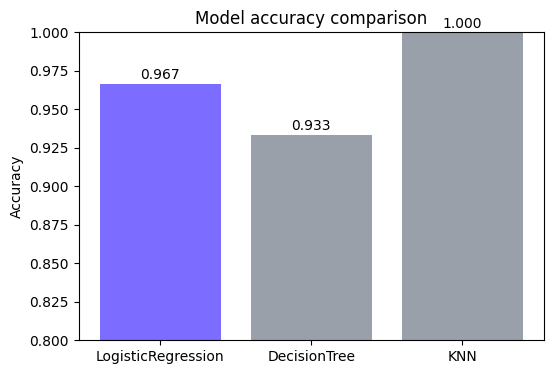

In [16]:
# 세 모델의 정확도를 막대그래프로 비교합니다.
plt.figure(figsize=(6, 4))
names = list(results.keys())
accs  = list(results.values())
bars = plt.bar(names, accs, color=['#7c6cff', '#9aa0aa', '#9aa0aa'])
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('Model accuracy comparison')
for bar, a in zip(bars, accs):            # 막대 위에 숫자 표시
    plt.text(bar.get_x() + bar.get_width()/2, a + 0.003, f"{a:.3f}", ha='center')
plt.show()

# 붓꽃은 쉬운 데이터라 세 모델 모두 90%대 후반으로 잘 맞힙니다.
# 보통은 이렇게 여러 모델을 비교한 뒤 가장 좋은 것을 고릅니다.

<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 2 이웃 수(k) 바꿔 비교</div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>KNeighborsClassifier</code>의 <code>n_neighbors</code>(참고할 이웃 수)를 <b>1</b>·<b>5</b>·<b>15</b>로 바꿔 각각 학습하고 평가용 정확도를 출력하세요.<br><b>힌트</b> &nbsp; 반복문이 돌 때마다 그 값을 <code>n_neighbors</code>에 넣고, 학습한 모델로 <code>X_test</code>의 답을 낸 뒤 <code>accuracy_score</code>로 정확도를 구합니다.<br><b>예상</b> &nbsp; k=1은 잡음에 민감 · 붓꽃은 쉬워 차이는 크지 않다
</div>
</div>

In [24]:
# ✏️ 연습문제 2 — 빈칸(____)을 채워 보세요
for k in [1, 5, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)   # 반복문이 돌 때마다 바뀌는 값
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))  # 새 데이터의 답을 내는 메서드
    print(f"k={k:2d} 정확도: {acc:.4f}")


k= 1 정확도: 0.9667
k= 5 정확도: 1.0000
k=15 정확도: 0.9667


## 5. 더 자세히 평가하기 — 혼동행렬과 리포트

정확도 하나만 보면 **어떤 품종을 어떤 품종으로** 헷갈렸는지 알 수 없습니다. **혼동행렬(confusion matrix)** 은 "실제 품종" 대 "예측 품종" 을 표로 만들어, 어디서 틀렸는지 보여 줍니다.

여기서는 위 비교에서 잘 나온 **LogisticRegression** 으로 자세히 살펴봅니다.

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

# 평가에 쓸 모델을 다시 학습시킵니다.
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 혼동행렬: 행=실제 품종, 열=예측 품종
cm = confusion_matrix(y_test, y_pred)
print(cm)
# 대각선(왼위→오른아래)에 있는 수가 '맞게 예측한 개수'입니다.
# 대각선 밖의 0 이 아닌 수가 '틀린(헷갈린) 경우'입니다.

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


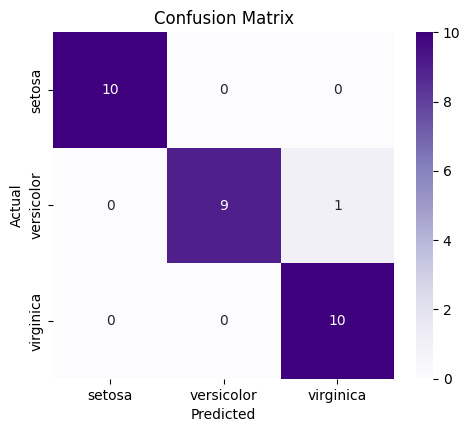

In [26]:
# 혼동행렬을 히트맵으로 그리면 어디서 틀렸는지 한눈에 보입니다.
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=iris.target_names,   # 열: 예측 품종
    yticklabels=iris.target_names    # 행: 실제 품종
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# setosa 는 완벽히 맞히고, 겹치던 versicolor/virginica 에서 한두 개 틀리는 정도입니다.

### classification_report 읽는 법

`classification_report` 는 품종마다 점수를 더 자세히 보여 줍니다.

- **precision(정밀도)**: 그 품종이라고 **예측한 것 중** 실제로 맞은 비율
- **recall(재현율)**: 그 품종인 **실제 것 중** 모델이 찾아낸 비율
- **f1-score**: precision 과 recall 의 균형 점수 (높을수록 좋음)

In [27]:
# target_names 를 넘기면 0/1/2 대신 품종 이름으로 보여 줍니다.
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 6. 왜 그렇게 분류했을까 — 결정 트리 들여다보기

머신러닝 모델은 종종 "왜 그렇게 판단했는지" 가 보이지 않습니다. 그런데 **결정 트리** 는 사람이 읽을 수 있는 **예/아니오 질문의 흐름도**라서, 어떤 기준으로 나눴는지 그림으로 볼 수 있습니다.

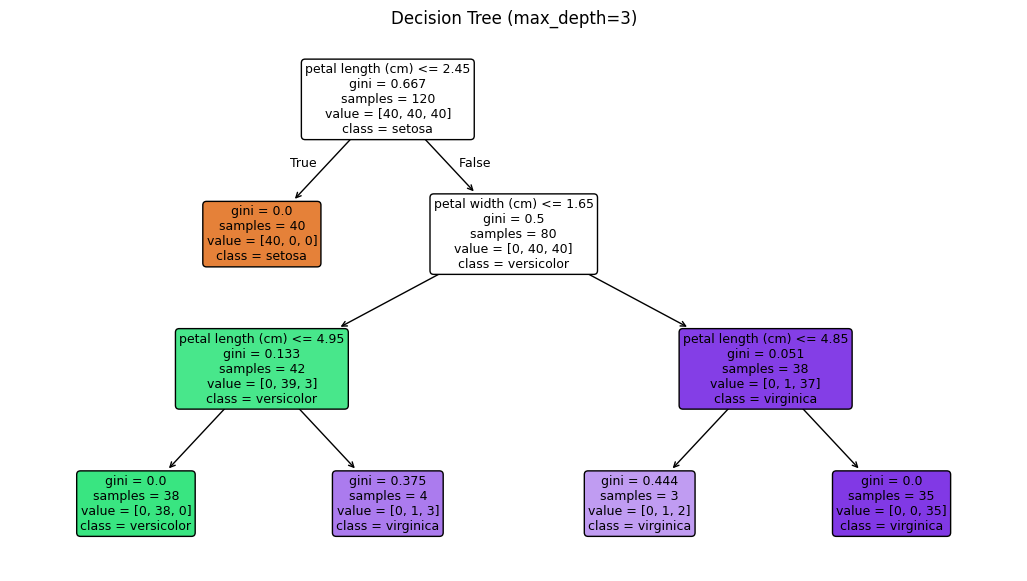

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 그림으로 보기 좋게, 깊이를 3으로 제한한 작은 트리를 학습합니다.
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

plt.figure(figsize=(13, 7))
plot_tree(
    tree,
    feature_names=iris.feature_names,   # 질문에 쓰인 특성 이름
    class_names=iris.target_names,      # 예측 품종 이름
    filled=True,                        # 품종별로 색칠
    rounded=True, fontsize=9
)
plt.title('Decision Tree (max_depth=3)')
plt.show()

# 읽는 법: 맨 위 질문(예: 'petal length <= 2.45?')부터 시작해,
#          맞으면 왼쪽 / 아니면 오른쪽으로 내려가며 품종을 좁혀 갑니다.
#          맨 아래 칸(leaf)의 class 가 최종 예측 품종입니다.

### 6.1 특성 중요도 — 어떤 측정값이 결정적이었나

트리가 품종을 나눌 때 어떤 특성을 많이 활용했는지 점수로 나타낸 것이 **특성 중요도(feature importance)** 입니다. 앞서 산점도에서 "꽃잎이 잘 나눈다" 고 본 직관을 숫자로 확인합니다.

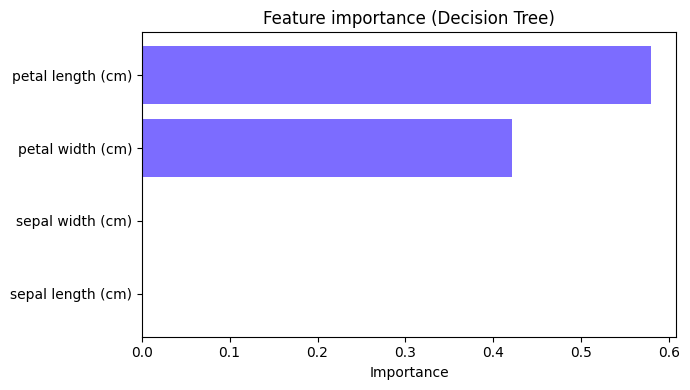

In [29]:
# .feature_importances_ : 각 특성이 분류에 기여한 정도(합이 1)
importances = tree.feature_importances_

# 보기 좋게 큰 순서로 정렬해 가로 막대로 그립니다.
order = np.argsort(importances)           # 작은→큰 순서의 인덱스
plt.figure(figsize=(7, 4))
plt.barh(np.array(iris.feature_names)[order], importances[order], color='#7c6cff')
plt.xlabel('Importance')
plt.title('Feature importance (Decision Tree)')
plt.tight_layout()
plt.show()

# 꽃잎(petal) 길이·너비의 중요도가 압도적으로 높게 나옵니다.
# 즉 이 트리는 주로 '꽃잎'을 보고 품종을 나누고 있다는 뜻입니다.

## 7. 새 데이터로 직접 예측해 보기

학습이 끝난 모델은 **새로 측정한 꽃** 의 품종도 예측할 수 있습니다. 측정값 4개를 넣어 `predict` 하면 됩니다. 입력 순서는 학습 때와 같아야 합니다 — `[꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃잎 너비]`.

In [30]:
# 새로 측정한 꽃 1송이 (단위 cm). 2차원 형태 [[...]] 로 넣는 점에 주의하세요.
new_flower = [[5.1, 3.5, 1.4, 0.2]]   # 꽃잎이 짧고 가늚 → setosa 같아 보이는 값

pred = clf.predict(new_flower)              # 품종 번호(0/1/2) 예측
print("예측 품종 번호:", pred[0])
print("예측 품종 이름:", iris.target_names[pred[0]])

# predict_proba: 각 품종일 '확률'도 볼 수 있습니다.
proba = clf.predict_proba(new_flower)[0]
for name, p in zip(iris.target_names, proba):
    print(f"  {name:12s}: {p*100:5.1f}%")

예측 품종 번호: 0
예측 품종 이름: setosa
  setosa      :  97.8%
  versicolor  :   2.2%
  virginica   :   0.0%


In [31]:
# 꽃잎이 큰 값을 넣어 보면 다른 품종으로 예측됩니다.
new_flower2 = [[6.7, 3.0, 5.2, 2.3]]   # 꽃잎이 길고 넓음 → virginica 같은 값
pred2 = clf.predict(new_flower2)
print("예측 품종:", iris.target_names[pred2[0]])

예측 품종: virginica


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 3 내가 정한 꽃 예측하기<span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 측정값 4개를 <b>직접 정해</b> <code>my_flower</code>에 넣고, 모델 <code>clf</code>가 어떤 품종으로 예측하는지 확인하세요. (예: <code>[[6.0, 2.7, 4.5, 1.5]]</code>)<br><b>힌트</b> &nbsp; 한 송이는 2차원 <code>[[...]]</code> 유지 · <code>iris.target_names[clf.predict(my_flower)[0]]</code><br><b>예상</b> &nbsp; 산점도에서 versicolor 자리의 값이면 versicolor로 예측
</div>
</div>

In [37]:
# ✏️ 연습문제 3 — 구조는 있으니 빈칸(____)의 로직만 채우세요
# 측정값 4개를 직접 정해 my_flower 에 넣고, clf 로 어떤 품종인지 예측합니다.
my_flower = [[2.3, 1.9, 3.3, 0.6]]                 # ← 한 송이를 2차원 [[...]] 로 (4개 측정값 직접 정하기)
pred = clf.predict(my_flower)                      # ← clf 로 품종 번호 예측
print("예측 품종:", iris.target_names[pred[0]])   # 번호 → 품종 이름

# (선택) 각 품종일 확률도 확인해 보세요
for name, p in zip(iris.target_names, clf.predict_proba(my_flower)[0]):
    print(f"  {name:12s}: {p*100:5.1f}%")


예측 품종: setosa
  setosa      :  68.4%
  versicolor  :  31.4%
  virginica   :   0.2%


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 4 학습 데이터를 줄이면<span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; <code>train_test_split</code>의 <code>test_size</code>를 <b>0.5</b>(절반을 평가용)로 바꿔 다시 나누고, <code>LogisticRegression</code>을 학습해 평가용 정확도를 출력하세요.<br><b>힌트</b> &nbsp; <code>random_state=42</code>·<code>stratify=y</code>는 그대로 · 결과는 새 변수(<code>X_tr, X_te, y_tr, y_te</code>)에 받기<br><b>예상</b> &nbsp; 붓꽃은 쉬워 크게 안 떨어지지만, 보통 학습이 줄면 불안정
</div>
</div>

In [40]:
# ✏️ 연습문제 4 — 흐름은 있으니 빈칸(____)만 채우세요
# test_size=0.5 로 다시 나눈 뒤 LogisticRegression 을 학습해 평가용 정확도를 출력합니다.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.5,random_state=42,stratify=y)    # ← train_test_split (test_size=0.5, random_state=42, stratify=y 유지)
m = LogisticRegression(max_iter=200)                         # ← 로지스틱 회귀 모델 (max_iter=200)
model.fit=(X_tr, y_tr)                             # ← 학습용(X_tr, y_tr)으로 학습
acc = accuracy_score(y_test, tree.predict(X_test))                       # ← 평가용 정답 y_te 와 예측을 비교해 정확도
print("test_size=0.5 정확도:", round(acc, 4))


test_size=0.5 정확도: 0.9667


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 5 비교할 모델 하나 더 추가<span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 4장의 <code>models</code> 딕셔너리에 <b>새 모델 하나</b>를 더 넣어 함께 정확도를 비교하세요. (예: <code>RandomForestClassifier(random_state=42)</code> 또는 <code>SVC()</code>)<br><b>힌트</b> &nbsp; <code>models["이름"] = 모델()</code>로 추가한 뒤 4장의 <code>for</code> 문 형태로 다시 평가<br><b>예상</b> &nbsp; 추가한 모델도 90%대 후반에서 함께 비교된다
</div>
</div>

In [43]:
# ✏️ 연습문제 5 — 빈칸(____)의 로직만 채우세요
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogisticRegression": LogisticRegression(max_iter=200),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "KNN":                KNeighborsClassifier(n_neighbors=5),
}

# 1) models 딕셔너리에 새 모델 하나를 추가
models["RandomForest"] = RandomForestClassifier(random_state=42)            # ← 이름과 모델 (예: RandomForest)

# 2) 4장에서 했던 것처럼 모든 모델을 학습·평가
for name, model in models.items():
    model.fit(X_tr, y_tr)                         # ← 학습용으로 학습
    acc = accuracy_score(y_test, tree.predict(X_test))                   # ← 평가용으로 예측한 뒤 정확도 계산
    print(f"{name:20s} 정확도: {acc:.4f}")


LogisticRegression   정확도: 0.9667
DecisionTree         정확도: 0.9667
KNN                  정확도: 0.9667
RandomForest         정확도: 0.9667


## 8. (도전 · 선택) 타이타닉 생존 분류 맛보기

붓꽃은 "세 품종 중 하나" 를 고르는 분류였습니다. 분류에는 **둘 중 하나**(예/아니오)를 맞히는 문제도 많은데, 이를 **이진 분류** 라 합니다. 대표 예제가 타이타닉 승객의 **생존 여부(생존/사망)** 예측입니다.

여기서는 seaborn 에 내장된 타이타닉 데이터로, 앞에서 배운 흐름(X·y 나누기 → 학습/평가 분리 → fit/predict → 정확도)이 **그대로** 적용된다는 점만 가볍게 확인합니다. 시간이 없으면 이 절은 건너뛰어도 됩니다.

In [44]:
# seaborn 내장 타이타닉 데이터 불러오기 (인터넷이 막혀 있으면 실패할 수 있습니다)
titanic = sns.load_dataset('titanic')
print("데이터 크기:", titanic.shape)
titanic[['survived', 'pclass', 'sex', 'age', 'fare']].head()
# survived: 1=생존, 0=사망 (이게 맞혀야 할 정답 y)
# pclass(객실 등급), sex(성별), age(나이), fare(요금) 등을 입력으로 씁니다.

데이터 크기: (891, 15)


,survived,pclass,sex,age,fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [45]:
# 간단히 4개 특성만 사용합니다.
cols = ['pclass', 'sex', 'age', 'fare']
data = titanic[cols + ['survived']].dropna()   # 결측값 있는 행은 제거(맛보기라 간단히)

# 모델은 숫자만 이해하므로, 글자 'male/female' 을 숫자로 바꿉니다.
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

X_t = data[cols]          # 입력 4개
y_t = data['survived']    # 정답 (생존 1 / 사망 0)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_t, y_t, test_size=0.2, random_state=42, stratify=y_t
)
print("학습용:", X_tr.shape, "/ 평가용:", X_te.shape)

학습용: (571, 4) / 평가용: (143, 4)


In [46]:
# 붓꽃 때와 똑같이 fit → predict → accuracy 로 평가합니다.
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_tr, y_tr)
y_p = model.predict(X_te)
print("타이타닉 생존 예측 정확도:", round(accuracy_score(y_te, y_p), 4))

# 어떤 특성이 생존 예측에 중요했는지도 같은 방법으로 볼 수 있습니다.
for name, imp in sorted(zip(cols, model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {name:8s}: {imp:.3f}")
# 보통 성별(sex)과 객실 등급(pclass)·요금(fare)이 생존에 크게 작용한 것으로 나옵니다.

타이타닉 생존 예측 정확도: 0.7972
  fare    : 0.313
  age     : 0.296
  sex     : 0.269
  pclass  : 0.122


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">✏️ 연습문제 6 타이타닉을 다른 모델로<span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">직접 작성</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 위 타이타닉 코드에서 <code>RandomForestClassifier</code> 대신 <b><code>LogisticRegression(max_iter=1000)</code></b>으로 학습하고 평가용 정확도를 출력하세요.<br><b>힌트</b> &nbsp; 앞서 만든 <code>X_tr, X_te, y_tr, y_te</code>를 그대로 재사용<br><b>예상</b> &nbsp; 트리 계열과 선형 모델의 점수를 견줘 볼 수 있다
</div>
</div>

In [ ]:
# ✏️ 연습문제 6 — 앞 셀의 타이타닉 분할(X_tr, X_te, y_tr, y_te)을 그대로 재사용
lr_t = ____                      # ← 로지스틱 회귀 모델 (max_iter=1000)
____                             # ← 학습용으로 학습
acc = ____                       # ← 평가용 정답과 예측을 비교해 정확도
print("LogisticRegression 정확도:", round(acc, 4))


<div style="border:1px solid #E7DCC6;border-left:6px solid #C15F3C;border-radius:10px;background:#FBF4EA;padding:16px 20px;margin:12px 0;">
<div style="font-size:16px;font-weight:700;color:#A8472A;margin-bottom:8px;">🎯 종합문제 꽃잎 2개 특성만으로 분류<span style="font-size:12px;color:#A8472A;background:#F0DCCF;padding:1px 8px;border-radius:10px;margin-left:6px;">종합</span></div>
<div style="color:#3D3A33;line-height:1.8;font-size:14.5px;">
<b>문제</b> &nbsp; 지금까지는 특성 4개를 모두 썼습니다. 이번엔 <b>꽃잎(petal) 길이·너비 2개</b>만으로 <code>RandomForestClassifier(random_state=42)</code>를 학습·평가하고, <b>4개 특성을 다 썼을 때의 정확도와 비교</b>해 두 값을 함께 출력하세요.<br><b>힌트</b> &nbsp; 앞서 만든 학습/평가 분할(<code>X_train</code>·<code>X_test</code>)에서 <b>꽃잎에 해당하는 두 열만 골라</b> 쓰면 됩니다(다시 나눌 필요 없음). 정확도는 <code>accuracy_score</code>로.<br><b>예상</b> &nbsp; 꽃잎 2개만으로도 4개 때 못지않은(때로는 더 높은) 정확도가 나온다 — 꽃잎이 품종을 잘 가른다
</div>
</div>

In [ ]:
# 🎯 종합문제 — 구조만 있으니 빈칸(____)의 로직을 스스로 채우세요
from sklearn.ensemble import RandomForestClassifier

# 앞서 나눈 X_train · X_test 를 다시 쓰되, 꽃잎(petal) 길이·너비 = 3·4번째 열만 골라 씁니다.
petal_cols = [2, 3]
X_train_petal = ____             # ← X_train 에서 petal_cols 두 열만 선택
X_test_petal  = ____             # ← X_test 에서 같은 두 열만 선택

# (1) 꽃잎 2개 특성만으로 학습·평가
rf_petal = ____                  # ← 랜덤 포레스트 (random_state=42)
____                             # ← 학습 (꽃잎 2열, y_train)
acc_petal = ____                 # ← 평가용(꽃잎 2열)으로 예측한 정확도

# (2) 4개 특성 전체로 학습·평가 (비교용)
rf_all = ____                    # ← 같은 모델 (random_state=42)
____                             # ← 학습 (X_train, y_train)
acc_all = ____                   # ← 정확도

print(f"꽃잎 2개 특성 정확도: {acc_petal:.4f}")
print(f"4개 특성 전체 정확도: {acc_all:.4f}")


## 🔑 막히면 펼쳐보기 (힌트)

아래는 위 연습문제가 막힐 때 참고할 **접근·메서드 힌트**입니다. 정답 코드가 아니니 먼저 스스로 시도해 보세요.

<details>
<summary>연습문제 1 · 꽃받침 산점도</summary>

- 꽃잎 산점도 코드에서 <code>x</code>·<code>y</code> 축 이름만 꽃받침으로 바꾸면 됩니다.
- 컬럼 이름은 <code>sepal length (cm)</code> · <code>sepal width (cm)</code> (헷갈리면 <code>df.columns</code> 확인).
</details>

<details>
<summary>연습문제 2 · 이웃 수(k) 바꿔 비교</summary>

- 반복문 변수 <code>k</code> 를 그대로 <code>n_neighbors=k</code> 로 넣습니다.
- 새 데이터의 답은 <code>모델.predict(X_test)</code>, 정확도는 <code>accuracy_score(정답, 예측)</code>.
</details>

<details>
<summary>연습문제 3 · 내가 정한 꽃 예측</summary>

- 한 송이는 대괄호 두 겹으로: <code>my_flower = [[a, b, c, d]]</code>.
- 예측은 <code>clf.predict(my_flower)</code> → 결과는 번호라 <code>iris.target_names[번호]</code> 로 이름 변환.
</details>

<details>
<summary>연습문제 4 · 학습 데이터 줄이기</summary>

- <code>train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)</code> 로 다시 나눕니다.
- 모델은 <code>.fit(학습X, 학습y)</code> → <code>.predict(평가X)</code>, 정확도는 <code>accuracy_score(평가y, 예측)</code>.
</details>

<details>
<summary>연습문제 5 · 모델 하나 더 추가</summary>

- 딕셔너리에 넣기: <code>models["RandomForest"] = RandomForestClassifier(random_state=42)</code>.
- 그다음 4장의 <code>for name, model in models.items(): ...</code> 반복을 그대로 다시 돌립니다.
</details>

<details>
<summary>연습문제 6 · 타이타닉을 다른 모델로</summary>

- 앞 셀에서 만든 <code>X_tr, X_te, y_tr, y_te</code> 를 그대로 재사용합니다.
- <code>LogisticRegression(max_iter=1000)</code> 을 만들어 <code>.fit</code> → <code>.predict</code> → <code>accuracy_score</code>.
</details>

<details>
<summary>종합문제 · 꽃잎 2개 특성만으로 분류</summary>

- numpy 배열에서 특정 열만 고르기: <code>X_train[:, [2, 3]]</code> (2·3번째 = 꽃잎 길이·너비).
- 꽃잎 2열용 모델과 4열 전체용 모델을 각각 <code>fit</code>·<code>predict</code> 해 두 정확도를 비교합니다.
- 다시 나눌 필요 없이 앞서 만든 <code>X_train</code>·<code>X_test</code>·<code>y_train</code>·<code>y_test</code> 를 씁니다.
</details>


## 9. 정리

- **분류**는 정답이 "범주(품종·생존 여부)" 인 문제로, 숫자 값을 맞히는 **회귀**(s4-04 집값)와 짝을 이룹니다.
- 모든 모델은 **`fit`(학습) → `predict`(예측)** 로 똑같이 쓰며, scikit-learn 덕분에 모델을 바꿔 끼우기 쉽습니다.
- 성능은 **정확도** 하나로 끝내지 말고, **혼동행렬·classification_report** 로 "어디서 틀렸는지" 까지 살핍니다.
- **결정 트리·특성 중요도** 로 "왜 그렇게 분류했는지" 를 들여다볼 수 있습니다.
- 학습한 모델은 **새 데이터** 의 품종을 예측할 수 있습니다.

이번 4차시에서는 **머신러닝** 으로 분류기를 직접 학습시켰습니다. 다음 **5차시** 에서는 같은 "분류" 문제를 **딥러닝(BERT)** 으로 풀어, 문장의 감정을 분류하고 RAG 챗봇까지 만들어 봅니다. 직접 만든 머신러닝 모델과 딥러닝 모델이 어떻게 다른지 비교해 보세요.